# Confronto tra modelli
Obiettivo: testare sistematicamente diversi algoritmi di classificazione, con lo stesso dataset e metodologia di valutazione, per dimostrare perché *Random Forest* è stato scelto come modello finale


In [14]:
import sys
sys.path.append("..") # Permette di importare src/ anche da dentro notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score 

from src.data_loading import load_raw_data, build_working_dataset
from src.features import build_all_features
from src.train import temporal_split, FEATURE_COL


In [15]:
sns.set_theme(style="whitegrid")

# Riusiamo la stessa pipeline di preparazione dati già validata
data = load_raw_data()
df = build_working_dataset(data["races"], data["results"], min_year=2004)
df = build_all_features(df, n_races=10)
train_df, test_df = temporal_split(df, 2023)

X_train, y_train = train_df[FEATURE_COL], train_df["podium"]
X_test, y_test = test_df[FEATURE_COL], test_df["podium"]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (7607, 6), Test: (912, 6)


## Funzione di valutazione comune

Per un confronto onesto, ogni modello viene valutato con la stessa logica: proviamo diverse soglie di decisione e teniamo quella che massimizza l'F1-score sulla classe podio

In [ ]:
def evaluate_with_best_threshold(model, X_train, y_train, X_test, y_test, thresholds=np.arange(0.1, 0.95, 0.05)):
    """
    Allena il modello, cerca la soglia che massimizza F1 sulla classe podio e ritorna un dizionario con le metriche al miglior punto
    """
    model.fit(X_train, y_train)

    # Non rurri i moswlli hanno 'predict_proba', gestiamo il caso generico
    y_proba = model.predict_proba(X_test)[:, 1]

    best_f1 = -1
    best_result = None

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_test, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_result = {
                "threshold": t,
                "precision": precision_score(y_test, y_pred),
                "recall": recall_score(y_test, y_pred),
                "f1 ": f1
            }

    return model, best_result

## Definizione dei modelli

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

RANDOM_STATE = 42

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, random_state=RANDOM_STATE # Non ha 'class_weight'. gestiamo lo sbilanciamento diversamente
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=4, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), # equivalente XGBoost di 'class_weight'
        random_state=RANDOM_STATE, eval_metric="logloss"
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE))
    ]),
    
}

In [19]:
results = []

for name, model in models.items():
    print(f"Addestramento: {name}...")
    trained_model, best = evaluate_with_best_threshold(model, X_train, y_train, X_test, y_test)
    results.append({"model": name, **best})

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
print("\n" + results_df.to_string(index=False))

Addestramento: Decision Tree...
Addestramento: KNN...
Addestramento: Logistic Regression...
Addestramento: Naive Bayes...
Addestramento: Random Forest...
Addestramento: Gradient Boosting...
Addestramento: XGBoost...
Addestramento: SVM...


/home/daniele/progetti/apex-predictor/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



              model  threshold  precision   recall       f1
      Random Forest       0.60   0.544643 0.884058 0.674033
      Decision Tree       0.85   0.618750 0.717391 0.664430
                KNN       0.30   0.542453 0.833333 0.657143
  Gradient Boosting       0.40   0.625000 0.688406 0.655172
Logistic Regression       0.75   0.545918 0.775362 0.640719
            XGBoost       0.40   0.508621 0.855072 0.637838
                SVM       0.40   0.514019 0.797101 0.625000
        Naive Bayes       0.80   0.469136 0.826087 0.598425


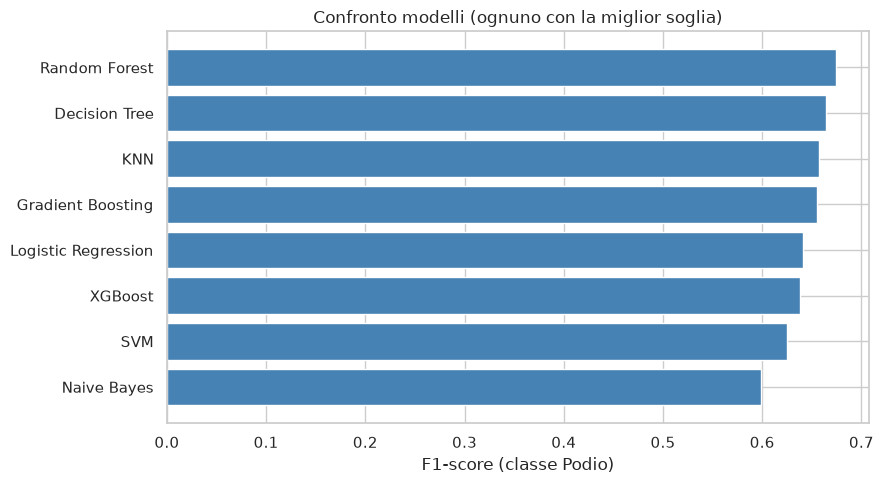

In [21]:
plt.figure(figsize=(9, 5))
results_df_sorted = results_df.sort_values("f1", ascending=True)
plt.barh(results_df_sorted["model"], results_df_sorted["f1"], color="steelblue")
plt.xlabel("F1-score (classe Podio)")
plt.title("Confronto modelli (ognuno con la miglior soglia)")
plt.tight_layout()
plt.show()